In [ ]:
# Load the Drive helper and mount
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip install -U -q alignn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.0/130.0 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 974.6/974.6 kB 24.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 619.9/619.9 MB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 95.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.3/515.3 kB 33.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 270.7/270.7 kB 19.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.3/125.3 kB 11.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 kB 6.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 53.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.4/261.4 kB 22.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.0/302.0 kB 20.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━

In [ ]:
from jarvis.core.atoms import Atoms
from alignn.ff.ff import AlignnAtomwiseCalculator, default_path, wt01_path, ForceField
model_path = wt01_path()
calculator = AlignnAtomwiseCalculator(path=model_path, stress_wt=0.3)

def atom_to_energy(atoms):
    num_atoms = atoms.num_atoms
    atoms = atoms.ase_converter()
    atoms.calc = calculator
    forces = atoms.get_forces()
    energy = atoms.get_potential_energy()
    stress = atoms.get_stress()
    return energy   # ,forces,stress

import glob
energies=[]
for i in glob.glob('/content/drive/MyDrive/MichaelWoodcox/NMC-811/PBE-D3/POSCARs/POSCAR*'):
    atoms=Atoms.from_poscar(i)
    en=atom_to_energy(atoms)
    print(atoms.composition.reduced_formula,i.split('/')[-1],en)
    energies.append(en)
    print(atoms)

dir_path /usr/local/lib/python3.10/dist-packages/alignn/ff/alignnff_wt01
model_path /usr/local/lib/python3.10/dist-packages/alignn/ff/alignnff_wt01
Li12MnCoNi10O24 POSCAR_12_Pristine -185.42744064331055
System
1.0
5.8106899261 0.0 0.0
-2.9053449631 5.0322050896 0.0
0.0 0.0 14.4018554688
Li Ni O Co Mn 
12 10 24 1 1 
direct
0.166666999 0.333332986 0.166666999 Li
0.166666999 0.833333015 0.166666999 Li
0.666666985 0.333332986 0.166666999 Li
0.666666985 0.833333015 0.166666999 Li
0.5 0.5 0.5 Li
0.5 0.0 0.5 Li
0.0 0.5 0.5 Li
0.0 0.0 0.5 Li
0.333332986 0.166666999 0.833333015 Li
0.333332986 0.666666985 0.833333015 Li
0.833333015 0.166666999 0.833333015 Li
0.833333015 0.666666985 0.833333015 Li
0.0 0.0 0.0 Ni
0.0 0.5 0.0 Ni
0.5 0.0 0.0 Ni
0.5 0.5 0.0 Ni
0.333332986 0.166666999 0.333332986 Ni
0.333332986 0.666666985 0.333332986 Ni
0.833333015 0.666666985 0.333332986 Ni
0.166666999 0.333332986 0.666666985 Ni
0.166666999 0.833333015 0.666666985 Ni
0.666666985 0.333332986 0.666666985 Ni
0.33333298

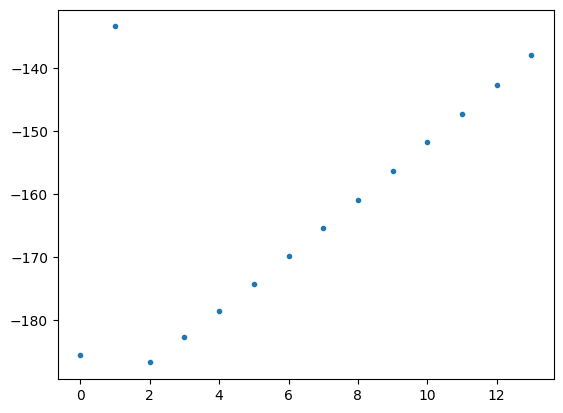

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.plot(energies,'.')

In [ ]:
!pip install jarvis-tools
from jarvis.db.figshare import data
import pandas as pd
dft3d = data('dft_3d')
df = pd.DataFrame(dft3d)

ions=['Li','Na','K','Ca','Mg','Al']
for i in ions:
    dff=df[df['dimensionality']=='intercalated ion']
    dff[i]=dff['atoms'].apply(lambda x: True if i in x['elements'] else False)
    print(i,len(dff[dff[i]==True]))

In [ ]:
from jarvis.db.figshare import data
import pandas as pd
dft3d = data('dft_3d')
df = pd.DataFrame(dft3d)

ions=['Li','Na','K','Ca','Mg','Al']
for i in ions:
    dff=df[df['dimensionality']=='intercalated ion']
    dff[i]=dff['atoms'].apply(lambda x: True if i in x['elements'] else False)
    print(i,len(dff[dff[i]==True]))


Obtaining 3D dataset 76k ...
Reference:https://www.nature.com/articles/s41524-020-00440-1
Other versions:https://doi.org/10.6084/m9.figshare.6815699


100%|██████████| 40.8M/40.8M [00:00<00:00, 62.8MiB/s]


Loading the zipfile...
Loading completed.


<ipython-input-6-64f1e8bad06b>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dff[i]=dff['atoms'].apply(lambda x: True if i in x['elements'] else False)
<ipython-input-6-64f1e8bad06b>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dff[i]=dff['atoms'].apply(lambda x: True if i in x['elements'] else False)


Li 7206
Na 3507


<ipython-input-6-64f1e8bad06b>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dff[i]=dff['atoms'].apply(lambda x: True if i in x['elements'] else False)


K 2791


<ipython-input-6-64f1e8bad06b>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dff[i]=dff['atoms'].apply(lambda x: True if i in x['elements'] else False)
<ipython-input-6-64f1e8bad06b>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dff[i]=dff['atoms'].apply(lambda x: True if i in x['elements'] else False)


Ca 3139
Mg 2218
Al 1036


<ipython-input-6-64f1e8bad06b>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dff[i]=dff['atoms'].apply(lambda x: True if i in x['elements'] else False)


In [ ]:
pos_nmc="""Li12MnCoNi10O24 POSCAR_12 -186.67831420898438
1.0
5.722199030358801 0.0316811905308191 0.034277072932368
-2.837205956893241 4.976234518508814 -0.0436569935674122
0.0842991813333899 -0.07514629745313 14.060768678603717
Li Ni O Co Mn
12 10 24 1 1
direct
0.1688327438331508 0.3297999591348769 0.1649956000974704 Li
0.172473890092873 0.8356864899746563 0.1685641023512929 Li
0.668427530285719 0.3282950689909331 0.1667312563038799 Li
0.6744149878689062 0.8343130844170392 0.1659318131470724 Li
0.4993358272026127 0.4984971806403814 0.4978378684548556 Li
0.5078921095808513 0.9993011041981975 0.5019303444438793 Li
0.9969612282011784 0.4966867240422818 0.5022244392144358 Li
0.9997282910326459 0.9971524691624708 0.5000009451390407 Li
0.3302049158954741 0.1721900425527386 0.8315900433189843 Li
0.3294466981882578 0.6745722802984955 0.8333745704545003 Li
0.8273791952776541 0.1632538133827845 0.8336883426787903 Li
0.8220402903645633 0.6694210268144737 0.8329618710150226 Li
0.0017861699936815 0.002581748070449 0.9985961119180445 Ni
0.0012639739857705 0.5027572891627887 0.9988855418058751 Ni
0.5011285691671211 0.0026743144426413 0.9989612062898856 Ni
0.5013485898829873 0.5027735791661624 0.9993335137368465 Ni
0.3356521074965844 0.1653040059586954 0.3339809270959171 Ni
0.3348067161510984 0.665162471675483 0.3337094404460684 Ni
0.835565494779512 0.6651379719355267 0.3336226413637411 Ni
0.163507389327034 0.3322451895703589 0.6673224791810208 Ni
0.1635624523155316 0.8325138125726035 0.6670106329629706 Ni
0.663660046972461 0.3325928682553302 0.6672321778297751 Ni
0.3626494197311564 0.189481262908058 0.0739654845617249 O
0.3156741528958645 0.641725170234906 0.0747750894443694 O
0.815964847212271 0.1424256924940673 0.0729483376721125 O
0.8638808950355965 0.689822939347853 0.07386926143925 O
9.72931502789e-05 0.0156002592876478 0.2525250341785849 O
0.9840111380950635 0.4844570927919453 0.257514905500024 O
0.5186358892067582 0.004219844614295 0.2557057801750228 O
0.5135404255297659 0.4989087064788484 0.26260554260048 O
0.1527692933280977 0.3266093884934385 0.4123132742887789 O
0.1571918333802295 0.8317705639268991 0.4054853987780477 O
0.6721215202584103 0.3149348765576293 0.4155830319394658 O
0.6863859407107992 0.8449675975587739 0.4092478560211913 O
0.3303809922662974 0.1630895489381796 0.5981038926628093 O
0.3451754272436531 0.6910077875637961 0.5914615435012331 O
0.8446418524818724 0.1494285752078169 0.5935252615253497 O
0.8042469018143871 0.6488083906756459 0.5920817242046146 O
0.9813343655903068 0.9728764837462701 0.7427153165962812 O
0.9973686652008895 0.5026726219504893 0.7361923532237752 O
0.5222348744487976 0.0160868429710899 0.7426919237219708 O
0.4810659252647246 0.5128796251583418 0.7423076755828479 O
0.139308547500604 0.3156289924761804 0.9233087084308679 O
0.1876536701568432 0.8629607085345264 0.9234008292158546 O
0.6860914657080085 0.3635188087600693 0.9235198423862067 O
0.6389806633977434 0.8156647120272628 0.9244997368433456 O
0.6633561810142145 0.8319861901578507 0.6674193488366255 Co
0.8358185124817221 0.1655547337187468 0.3337467954197821 Mn
"""
from jarvis.io.vasp.inputs import Poscar
atoms_nmc=Poscar.from_string(pos_nmc).atoms

In [ ]:
atom_to_energy(atoms_nmc)

-186.67831420898438

In [ ]:
from jarvis.core.specie import Specie
s=Specie('Li')

In [ ]:
Specie('Al').element_property('min_oxid_s')

1.0

In [ ]:
from jarvis.analysis.thermodynamics.energetics import unary_energy
unary_energy('Ca')

0.57921958

In [ ]:
atoms_nmc.lattice_mat

array([[ 5.72219903,  0.03168119,  0.03427707],
       [-2.83720596,  4.97623452, -0.04365699],
       [ 0.08429918, -0.0751463 , 14.06076868]])

In [ ]:
from jarvis.analysis.thermodynamics.energetics import unary_energy
def get_voltage_profile(atoms=[],element='Li',charge=None):
    if charge is None:
      charge=abs(Specie(element).element_property('min_oxid_s'))
    chem_pot = charge*unary_energy(element)

    #print('charge',element,charge)
    elements = atoms.elements
    coords = atoms.frac_coords
    lattice_mat = atoms.lattice_mat

    new_elements = []
    new_coords = []
    options = []
    for ii, i in enumerate(elements):
        if i == element:
            options.append(ii)
    comb = []
    for i in range(len(options)):
      comb.append(options[0:i+1])

    mem=[]
    info={}
    info['atoms']=atoms
    info['comb']=[]
    perf_en=atom_to_energy(atoms)
    info['en']=perf_en

    mem.append(info)
    for ii, i in enumerate(comb):
      new_elements=[]
      new_coords=[]
      for jj,j in enumerate(elements):
          if jj not in i:
            new_elements.append(j)
            new_coords.append(coords[jj])
      new_atoms = Atoms(
            coords=new_coords,
            lattice_mat=lattice_mat,
            elements=new_elements,
            cartesian=False,
      )
      en=atom_to_energy(new_atoms)
      info={}
      info['en']=en
      info['atoms']=new_atoms#.to_dict()
      info['comb']=i
      mem.append(info)

    max_en=max([i['en'] for i in mem])
    voltages=[]
    for ii,i in enumerate(mem):
      if ii<len(mem)-1:
        temp=mem[ii+1]['en']-mem[ii]['en']-0.925 #,len(i['comb']))
        voltages.append(temp)
    return voltages
#voltages=get_voltage_profile(atoms=atoms_nmc)

In [ ]:
voltages

[3.246794652938843,
 3.643208932876587,
 3.8448111534118654,
 4.296290111541748,
 3.466739845275879,
 3.8654739379882814,
 4.294531059265137,
 4.400144767761231,
 3.351425123214722,
 4.160931539535523,
 4.600238513946533,
 4.741939735412598]

In [ ]:
from jarvis.db.figshare import data
import pandas as pd
dft3d = data('dft_3d')
df = pd.DataFrame(dft3d)
dff=df[df['dimensionality']=='intercalated ion']
dff['Li']=dff['atoms'].apply(lambda x: True if 'Li' in x['elements'] else False)
dffLi=(dff[dff['Li']==True])

Obtaining 3D dataset 76k ...
Reference:https://www.nature.com/articles/s41524-020-00440-1
Other versions:https://doi.org/10.6084/m9.figshare.6815699
Loading the zipfile...
Loading completed.


<ipython-input-8-f7a34bad48ec>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dff['Li']=dff['atoms'].apply(lambda x: True if 'Li' in x['elements'] else False)


In [ ]:
from jarvis.core.specie import Specie
for i,ii in dffLi.iterrows():
  #try:
    atoms=Atoms.from_dict(ii['atoms'])
    voltages=get_voltage_profile(atoms=atoms)
    print(ii['jid'],ii['formula'],ii['ehull'],max(voltages),voltages)
  #except:
  #  pass

NameError: ignored

In [ ]:
for i,ii in dffLi.iterrows():
  try:
    atoms=Atoms.from_dict(ii['atoms'])
    voltages=get_voltage_profile(atoms=atoms)
    print(ii['jid'],ii['formula'],ii['ehull'],max(voltages),voltages)
  except:
    pass

JVASP-97915 Ba14Na14LiN6 0.0 0.9698371410369873 [0.9698371410369873]
JVASP-42300 Li4Mn3Cr3O12 0.094 3.9227292060852053 [2.6443478584289553, 2.5865408897399904, 2.974336338043213, 3.9227292060852053]
JVASP-86436 LiSbF6 0.0 5.473091316223145 [5.473091316223145]
JVASP-48166 LiMn5O3F5 0.0 2.4579841613769533 [2.4579841613769533]
JVASP-64377 Ba4LiHf 0.8441 0.9231776714324951 [0.9231776714324951]
JVASP-86322 LiO 0.0107 5.496364307403565 [3.5611664772033693, 3.8593003273010256, 5.0528285026550295, 5.496364307403565]
JVASP-47962 Li2VO2F 0.0588 5.68950719833374 [3.836316776275635, 5.68950719833374]
JVASP-18433 LiNiO2 0.0326 3.7602819919586183 [3.7602819919586183]
JVASP-43739 LiFeF3 0.0711 5.5347411155700685 [4.854980182647705, 5.5347411155700685]
JVASP-49773 LiTaO3 0.1045 3.9022614479064943 [3.9022614479064943, 3.1007554054260256]
JVASP-43424 Li2MnCuO4 0.1199 4.869852733612061 [3.0664059638977053, 4.171255779266358, 4.385908794403076, 4.869852733612061]
JVASP-1837 LiYSe2 0.0 2.668394756317139 [2

In [ ]:
ii['ehull']

0.0107

In [ ]:
dff['Ca']=dff['atoms'].apply(lambda x: True if 'Ca' in x['elements'] else False)

(dff[dff['Ca']==True])

<ipython-input-6-9602429c6979>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dff['Ca']=dff['atoms'].apply(lambda x: True if 'Ca' in x['elements'] else False)


,jid,spg_number,spg_symbol,formula,formation_energy_peratom,func,optb88vdw_bandgap,atoms,slme,magmom_oszicar,...,raw_files,nat,bulk_modulus_kv,shear_modulus_gv,mbj_bandgap,hse_gap,reference,search,Li,Ca
37,JVASP-63912,216,F-43m,Ba4CaRe,1.18903,OptB88vdW,0.000,"{'lattice_mat': [[0.0, 4.893247728183244, 4.89...",na,0.0,...,"[OPT-Bandst,JVASP-63912.zip,https://ndownloade...",6,na,na,na,na,auid-1a8e7b7b5bf25a3b,-Ba-Ca-Re,False,True
48,JVASP-65062,216,F-43m,Ca4BeW,1.23549,OptB88vdW,0.000,"{'lattice_mat': [[-0.0, 4.326757913323647, 4.3...",na,3.608,...,"[FD-ELAST,JVASP-65062.zip,https://ndownloader....",6,23.03,13.82,na,na,auid-27f8ee313e77474b,-Be-Ca-W,False,True
66,JVASP-64780,216,F-43m,Ba4CaSn,0.16814,OptB88vdW,0.000,"{'lattice_mat': [[0.0, 5.160847896472875, 5.16...",na,0.0,...,"[OPT-LOPTICS,JVASP-64780.zip,https://ndownload...",6,na,na,na,na,auid-dfb538f160f33c79,-Ba-Ca-Sn,False,True
142,JVASP-52881,12,C2/m,K3CaP2HO8,-2.50095,OptB88vdW,5.395,"{'lattice_mat': [[4.9395625275590636, 2.872916...",0.0,0.0,...,"[OPT-LOPTICS,JVASP-52881.zip,https://ndownload...",15,na,na,8.178,na,mp-696878,-Ca-H-K-O-P,False,True
182,JVASP-97576,217,I-43m,Ca4Al6SO12,-3.24073,OptB88vdW,3.685,"{'lattice_mat': [[7.394501076210965, -1.65096e...",na,0.0,...,[],23,na,na,na,na,mp-8876,-Al-Ca-O-S,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75871,JVASP-155562,115,P-4m2,Ca2CdTe2F2,-2.34155,OptB88vdW,1.494,"{'lattice_mat': [[4.108127674210693, 0.0, -0.0...",na,0.0,...,[],7,na,na,na,na,1250102,-Ca-Cd-F-Te,False,True
75885,JVASP-156254,194,P6_3/mmc,CaAsPt,-1.03740,OptB88vdW,0.000,"{'lattice_mat': [[2.1301941508227724, -3.68962...",na,0.0,...,[],6,na,na,na,na,1283151,-As-Ca-Pt,False,True
75895,JVASP-155563,115,P-4m2,Ca2HgTe2F2,-2.19477,OptB88vdW,0.727,"{'lattice_mat': [[4.119689596468836, 0.0, 0.0]...",na,0.0,...,[],7,50.8,19.6,na,na,1250111,-Ca-F-Hg-Te,False,True
75902,JVASP-155757,139,I4/mmm,CaMg2Al2,-0.19114,OptB88vdW,0.000,"{'lattice_mat': [[-2.210655152404384, 2.210655...",na,0.0,...,[],5,37.06,-13.61,na,na,1253148,-Al-Ca-Mg,False,True


In [ ]:
x=[]
for i in dft3d:
  if 'Ca' in i['atoms']['elements'] and 'S' in i['atoms']['elements']:
    x.append(i)
dff=pd.DataFrame(x)

In [ ]:
dff

,jid,spg_number,spg_symbol,formula,formation_energy_peratom,func,optb88vdw_bandgap,atoms,slme,magmom_oszicar,...,density,poisson,raw_files,nat,bulk_modulus_kv,shear_modulus_gv,mbj_bandgap,hse_gap,reference,search
0,JVASP-97576,217,I-43m,Ca4Al6SO12,-3.24073,OptB88vdW,3.685,"{'lattice_mat': [[7.394501076210965, -1.65096e...",na,0.0,...,2.442,na,[],23,na,na,na,na,mp-8876,-Al-Ca-O-S
1,JVASP-98203,62,Pnma,CaSc2S4,-2.18950,OptB88vdW,1.269,"{'lattice_mat': [[3.7295549502559893, -0.0, 0....",na,0.0,...,2.962,na,[],28,na,na,na,na,mp-17597,-Ca-S-Sc
2,JVASP-62215,217,I-43m,Ca4Al6SO12,-3.23192,OptB88vdW,3.808,"{'lattice_mat': [[-4.538678787064536, 4.538678...",0.0,0.0,...,2.425,na,"[OPT-LOPTICS,JVASP-62215.zip,https://ndownload...",23,na,na,6.33,na,auid-d54bc3d76ca2666e,-Al-Ca-O-S
3,JVASP-98086,1,P1,Ba4Na2CaTi3Si4S2O26,-2.87935,OptB88vdW,2.181,"{'lattice_mat': [[5.448049715243068, 0.0031059...",na,0.0,...,3.996,na,[],42,na,na,na,na,mp-561052,-Ba-Ca-Na-O-S-Si-Ti
4,JVASP-1333,225,Fm-3m,CaS,-2.38214,OptB88vdW,2.347,"{'lattice_mat': [[3.4800360873590304, -8.72205...",2.32,0.0,...,2.611,0.22,"[FD-ELAST,JVASP-1333.zip,https://ndownloader.f...",2,61.57,43.96,3.289,na,mp-1672,-Ca-S
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147,JVASP-132442,1,P1,CaS31,-0.10799,OptB88vdW,1.199,"{'lattice_mat': [[7.839990488488424, -0.060571...",na,0.0,...,2.148,na,[],32,na,na,na,na,JVASP-95268,-Ca-S
148,JVASP-121549,2,P-1,K2Ca2MgH2S4O16,-1.80793,OptB88vdW,2.148,"{'lattice_mat': [[6.408008965671279, 0.1471195...",na,2.0,...,2.769,na,[],27,na,na,na,na,mp-1212031,-Ca-H-K-Mg-O-S
149,JVASP-137229,12,C2/m,Ca2Sn3S8,-0.96299,OptB88vdW,1.041,"{'lattice_mat': [[7.55102724917484, 0.01029023...",23.76,0.0,...,3.579,na,[],13,na,na,1.964,na,mp-1100342,-Ca-S-Sn
150,JVASP-145308,63,Cmcm,KCaEr2CuS5,-1.93470,OptB88vdW,1.343,"{'lattice_mat': [[7.014088323685876, 0.0105906...",na,0.0,...,4.696,na,[],20,na,na,na,na,mp-1211692,-Ca-Cu-Er-K-S
